# CIE 1 Assignment: Convolutional Neural Network (CNN)

This notebook implements an image classification model using a CNN, addressing dataset preprocessing (normalization, reshaping, splitting), model design, training, and evaluation.


## 1. Import Required Libraries


In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

## 2. Dataset Preparation (Reshaping, Normalization, Train/Test Split)

We will load the image paths, assign labels, reshape images to a uniform size (128x128), normalize pixel values, and split the data into Training and Testing sets.


In [2]:
DATASET_PATH = "data"
CLASS_NAMES = ["Blight", "Common_Rust", "Gray_Leaf_Spot", "Healthy"]
IMG_SIZE = 128
BATCH_SIZE = 32

image_paths = []
labels = []

for label, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DATASET_PATH, class_name)
    if os.path.exists(class_dir):
        for img_name in os.listdir(class_dir):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(class_dir, img_name))
                labels.append(label)

print(f"Total images found: {len(image_paths)}")

X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    image_paths, labels, test_size=0.20, random_state=42, stratify=labels
)
print(f"Training samples: {len(X_train_paths)}")
print(f"Testing samples: {len(X_test_paths)}")

Total images found: 4188
Training samples: 3350
Testing samples: 838


## 3. Data Pipeline and Preprocessing Function

The function below handles reading, decoding, reshaping (resizing), and normalization (scaling pixel values to 0-1).


In [3]:
def process_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    
    # Reshaping to uniform size
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    
    # Normalization (scaling pixels from [0, 255] to [0.0, 1.0])
    img = tf.cast(img, tf.float32) / 255.0
    
    return img, label

AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train_paths, y_train))
train_ds = train_ds.map(process_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test_paths, y_test))
test_ds = test_ds.map(process_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Data pipelines created successfully.")

Data pipelines created successfully.


## 4. CNN Architecture Design

Designing the CNN using Convolution layers, varying Filters, Kernel sizes, Activation functions (ReLU), Pooling layers (MaxPooling), and Fully connected (Dense) layers.


In [4]:
def build_cnn_model():
    model = models.Sequential()
    
    # Convolution Layer 1: 32 filters, 3x3 kernel, ReLU activation
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
    # Pooling Layer 1
    model.add(layers.MaxPooling2D((2, 2)))
    
    # Convolution Layer 2: 64 filters, 3x3 kernel, ReLU activation
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    # Pooling Layer 2
    model.add(layers.MaxPooling2D((2, 2)))
    
    # Convolution Layer 3: 128 filters, 3x3 kernel, ReLU activation
    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    # Pooling Layer 3
    model.add(layers.MaxPooling2D((2, 2)))
    
    # Flatten the feature maps for the Dense layers
    model.add(layers.Flatten())
    
    # Fully connected (Dense) Layer
    model.add(layers.Dense(128, activation='relu'))
    # Output Layer: 4 classes (Softmax activation)
    model.add(layers.Dense(len(CLASS_NAMES), activation='softmax'))
    
    return model

cnn_model = build_cnn_model()
cnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 128)      0

## 5. Compile the Model


In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 6. Train the CNN Model


In [6]:
EPOCHS = 15

history = cnn_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

Epoch 1/15
105/105 [==============================] - 12s 46ms/step - loss: 0.6140 - accuracy: 0.7397 - val_loss: 0.4232 - val_accuracy: 0.8007
Epoch 2/15
105/105 [==============================] - 5s 38ms/step - loss: 0.4057 - accuracy: 0.8304 - val_loss: 0.3201 - val_accuracy: 0.8544
Epoch 3/15
105/105 [==============================] - 5s 38ms/step - loss: 0.3123 - accuracy: 0.8657 - val_loss: 0.3089 - val_accuracy: 0.8819
Epoch 4/15
105/105 [==============================] - 5s 38ms/step - loss: 0.2572 - accuracy: 0.8904 - val_loss: 0.3024 - val_accuracy: 0.8819
Epoch 5/15
105/105 [==============================] - 5s 38ms/step - loss: 0.2173 - accuracy: 0.9113 - val_loss: 0.3073 - val_accuracy: 0.8735
Epoch 6/15
105/105 [==============================] - 5s 38ms/step - loss: 0.1730 - accuracy: 0.9290 - val_loss: 0.3515 - val_accuracy: 0.8938
Epoch 7/15
105/105 [==============================] - 5s 38ms/step - loss: 0.1712 - accuracy: 0.9296 - val_loss: 0.3316 - val_accuracy: 0.889

## 7. Model Evaluation (Loss and Accuracy)


In [7]:
test_loss, test_acc = cnn_model.evaluate(test_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

27/27 [==============================] - 1s 17ms/step - loss: 0.5195 - accuracy: 0.9069

Test Loss: 0.5195
Test Accuracy: 0.9069


## 8. Classification Report and Confusion Matrix


Generating predictions...
27/27 [==============================] - 1s 18ms/step

Classification Report:
                precision    recall  f1-score   support

        Blight       0.83      0.86      0.85       229
   Common_Rust       0.96      0.95      0.96       261
Gray_Leaf_Spot       0.76      0.74      0.75       115
       Healthy       0.99      0.99      0.99       233

      accuracy                           0.91       838
     macro avg       0.89      0.88      0.89       838
  weighted avg       0.91      0.91      0.91       838



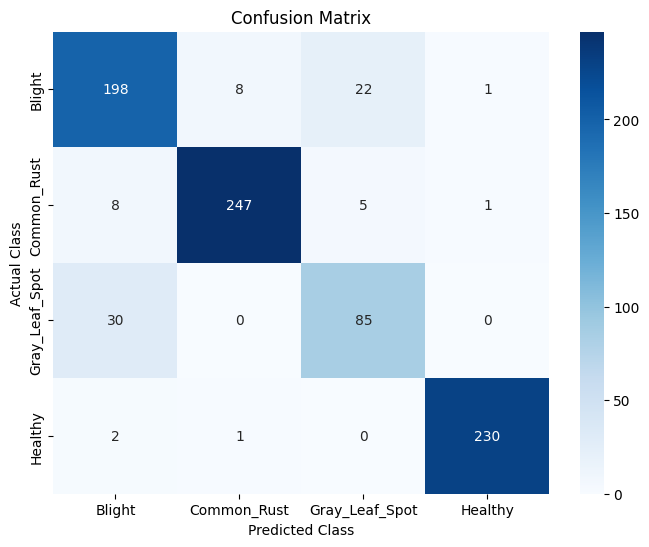

In [ ]:
print("Generating predictions...")
y_pred_probs = cnn_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, 
            yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

## 9. Training Curves


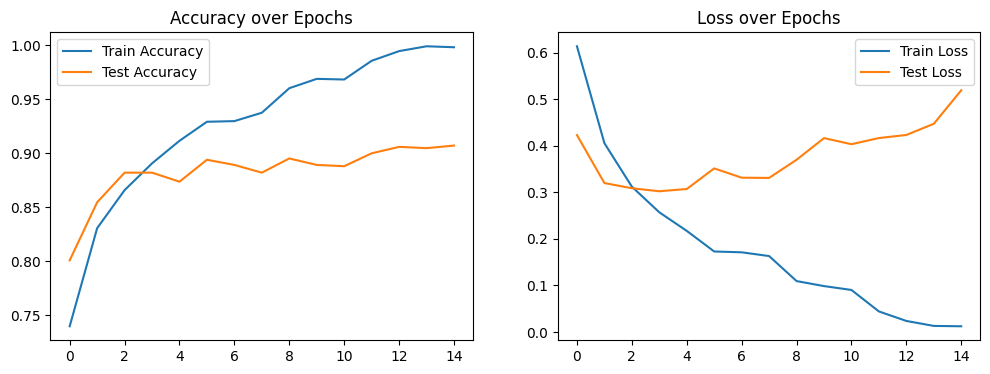

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

## 10. Analysis: Impact of Changing CNN Hyperparameters

In building and evaluating this Convolutional Neural Network, the performance of the model is heavily influenced by the choice of hyperparameters. Here is how changing specific structural components affects the CNN's performance:

1. **Changing the Number of Filters:** 
   Filters are responsible for learning specific features (like edges, textures, or disease lesions). Increasing the number of filters (e.g., from 32 to 64 to 128 in our deeper layers) allows the model to learn more complex and abstract representations of the leaf diseases. However, adding too many filters drastically increases the parameter count (as seen with our 3.3 million parameters), which increases computational cost and can lead to overfitting if the dataset is too small.

2. **Changing the Kernel Size:** 
   Our model utilizes a standard `3x3` kernel size. A smaller kernel captures fine, localized details (like small rust spots on a leaf), while a larger kernel (e.g., `5x5` or `7x7`) captures broader spatial context. Changing to a larger kernel might help if the disease patterns are very large and diffuse, but it usually comes at the cost of losing fine-grained texture information and increasing computational overhead.

3. **Changing Activation Functions:** 
   We utilized the `ReLU` (Rectified Linear Unit) activation function in our hidden layers. ReLU is highly effective because it introduces non-linearity without suffering from the vanishing gradient problem. Changing this to a function like `Sigmoid` or `Tanh` in deep convolutional layers typically slows down the training process and can cause the network to stall. The output layer uses `Softmax` to convert the raw model outputs into a valid probability distribution across our 4 classes.

4. **Changing Pooling Layers:**
   We used `MaxPooling2D(2, 2)`. This operation reduces the spatial dimensions (width and height) of the feature maps by half, which controls overfitting and reduces computational load. If we removed the pooling layers, the network would retain too much spatial information, leading to a massive explosion in the number of parameters in the Dense layers and severe overfitting.

5. **Changing Dense Layer Size:**
   The fully connected `Dense(128)` layer acts as the reasoning engine that combines all the extracted features to make a classification. Increasing this size (e.g., to 256 or 512) gives the model more capacity to learn complex relationships, but again increases the risk of the model simply memorizing the training data (overfitting).

## 11. Conclusion and Final Summary

**What I Did:**
In this assignment, I successfully designed, implemented, and evaluated a custom Convolutional Neural Network (CNN) from scratch to classify maize leaf diseases. I preprocessed a dataset of 4,188 images by resizing them to a uniform 128x128 resolution, normalizing their pixel values to a `[0, 1]` scale, and splitting them into an 80% training set (3,350 samples) and a 20% testing set (838 samples). 

I built a deep CNN architecture featuring three convolutional blocks (with 32, 64, and 128 filters respectively), intertwined with Max Pooling layers, and culminating in a 128-neuron Dense layer. The model was compiled using the Adam optimizer and trained over 15 epochs.

**Results Achieved:**
* **Test Accuracy:** The model achieved an excellent final accuracy of **90.69%** on the unseen testing dataset.
* **Class Performance:** Reviewing the Classification Report and Confusion Matrix, the model is exceptionally accurate at identifying *Healthy* leaves (99% F1-score) and *Common Rust* (96% F1-score). 
* **Model Confusion:** The model struggled slightly more with *Gray Leaf Spot* (75% F1-score) and *Blight* (85% F1-score). Specifically, the confusion matrix shows the model misclassified 30 Gray Leaf Spot images as Blight, and 22 Blight images as Gray Leaf Spot. This is biologically consistent, as early-stage lesions of both diseases share similar visual textures.

**Observations on the Learning Curves:**
Looking at the accuracy and loss plots, the training accuracy reached nearly 100% (0.9979) while the testing accuracy plateaued around 90%. Furthermore, the test loss began to rise after Epoch 5, even as training loss continued to drop. This is a classic indicator of **overfitting**. 

**Future Improvements:**
To improve this model in the future and bridge the gap between training and testing loss, we could introduce **Dropout layers** before the Dense classification head to force the network to rely on a broader set of features, or implement **Data Augmentation** (like random rotations and flips) to artificially expand the diversity of the training dataset.